# 多项式回归
简单来说，多项式回归是线性回归的一种扩展。它通过为原始特征添加高次项（如平方项、立方项），将数据映射到更高维度的空间，从而用一条"曲线"来拟合数据中存在的非线性关系。

-----

## 一. 核心概念 : 从直线到曲线



### 1.1 引入多项式回归
多项式回归的核心思想是：将特征的高次幂视为新的特征，然后在这个扩展后的特征集上应用线性回归。

例如，一个二次多项式回归模型：$y=w_1 * x + w_2 * x^2 + b$

虽然方程里出现了$x^2$ , 但如果我们把 x 和 $x^2$ 视为两个特征 X1 和 X2，那么这个模型就变成了一个线性模型。
即：$y=w_1 * X1 + w_2 * X2 + b$

多项式回归是线性回归的拓展，它允许我们使用高次幂特征来拟合非线性关系。

### 1.2 关键术语
- 阶数/次数：多项式回归模型中，特征的最高次幂。
- 过拟合 : 如果选择的阶数太高，模型会变得非常"曲折"，完美穿过所有训练数据点，但对新数据的预测能力会急剧下降。就像用一张复杂的网去捕捉几个点，网眼太细，反而抓不住大鱼。
- 欠拟合 : 如果阶数太低（比如用直线去拟合明显弯曲的数据），模型无法捕捉数据中的基本模式，预测能力同样很差。

![alt text](ml-multinomial-regression-runoob.png)

----

## 二 . 用 Python 实现多项式回归

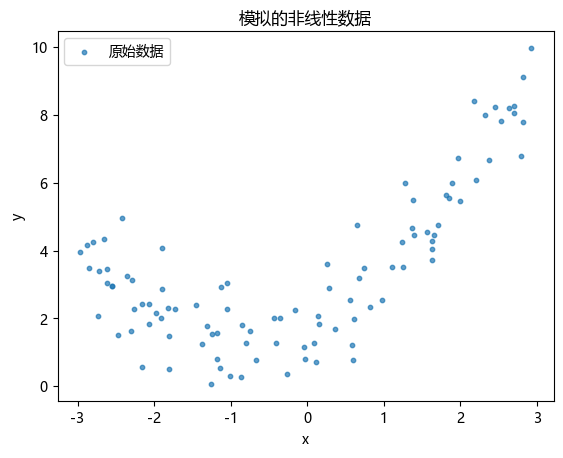

In [25]:
# 1. 准备环境与数据
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures        # 多项式特征
from sklearn.metrics import mean_squared_error, r2_score

# 设置随机种子 , 确保每次运行结果一致
np.random.seed(42)

# 创建模拟数据 : y 是 x 的二次函数加上一些随机噪声
X = 6 * np.random.rand(100, 1) - 3          # 生成 100 个在 [-3, 3) 之间的随机数
y = 0.5 * X ** 2 + X + 2 + np.random.randn(100 , 1)          # y = 0.5x^2 + x + 2 + 噪声


plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False
# 可视化原始数据
plt.scatter(X, y, s=10, alpha=0.7, label='原始数据')
plt.xlabel('x')
plt.ylabel('y')
plt.title('模拟的非线性数据')
plt.legend()
plt.show()

In [26]:
# 2. 特征转换与模型训练

# 创建多项式特征
# 参数 degree 决定了多项式的阶数 , 这里我们尝试选择 2 阶
poly_features = PolynomialFeatures(degree=2 , include_bias=False)               # include_bias=False 表示不添加偏置项 , 因为线性回归模型已经包含了偏置项
# 将原始特征 X 转换为包含 X 和 X^2 的多项式特征矩阵X_poly
X_poly = poly_features.fit_transform(X)

print(f"原始X的形状: {X.shape}")
print(f"转换后的X_poly的形状: {X_poly.shape}")
print(f"转换后的X_poly的前五行: {X_poly[:5]}")
# 输出显示 , X_poly 有两列 : 第一列是原始特征 X , 第二列是 X^2 , 这两个特征用于训练模型


# 在转换的特征上训练线性模型
lin_reg = LinearRegression()
lin_reg.fit(X_poly, y)          # 使用X_poly , 而不是原始特征X


# 查看学到的模型参数(权重和偏置项)
print(f"\n模型的权重: {lin_reg.coef_.ravel()}")             # ravel() 方法将权重向量转换为一维数组 , 方便查看
print(f"\n模型的偏置项: {lin_reg.intercept_}")

原始X的形状: (100, 1)
转换后的X_poly的形状: (100, 2)
转换后的X_poly的前五行: [[-0.75275929  0.56664654]
 [ 2.70428584  7.3131619 ]
 [ 1.39196365  1.93756281]
 [ 0.59195091  0.35040587]
 [-2.06388816  4.25963433]]

模型的权重: [0.93366893 0.56456263]

模型的偏置项: [1.78134581]


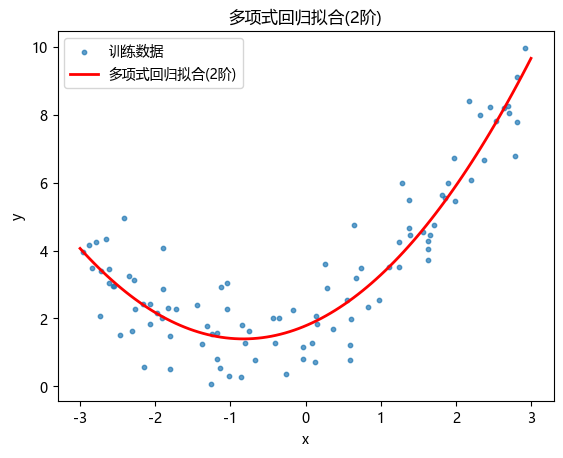

In [27]:
# 可视化拟合效果

# 为了画出平滑的曲线 , 需要生成一组均匀分布的点
X_new = np.linspace(-3 , 3 , 100).reshape(100 , 1)
# 对这组新点进行多项式特征转换
X_new_poly = poly_features.transform(X_new)
# 用模型进行预测
y_new = lin_reg.predict(X_new_poly)


# 开始绘图
plt.scatter(X , y , s = 10 , alpha = 0.7 , label = "训练数据")
plt.plot(X_new , y_new , 'r-' , linewidth=2 , label = "多项式回归拟合(2阶)")
plt.xlabel('x')
plt.ylabel('y')
plt.title('多项式回归拟合(2阶)')
plt.legend()
plt.show()


------

## 三. 如何选择多项式特征的次数
选择阶数是一个权衡过程 , 我们可以通过可视化不同阶数的拟合效果来选择合适的阶数。

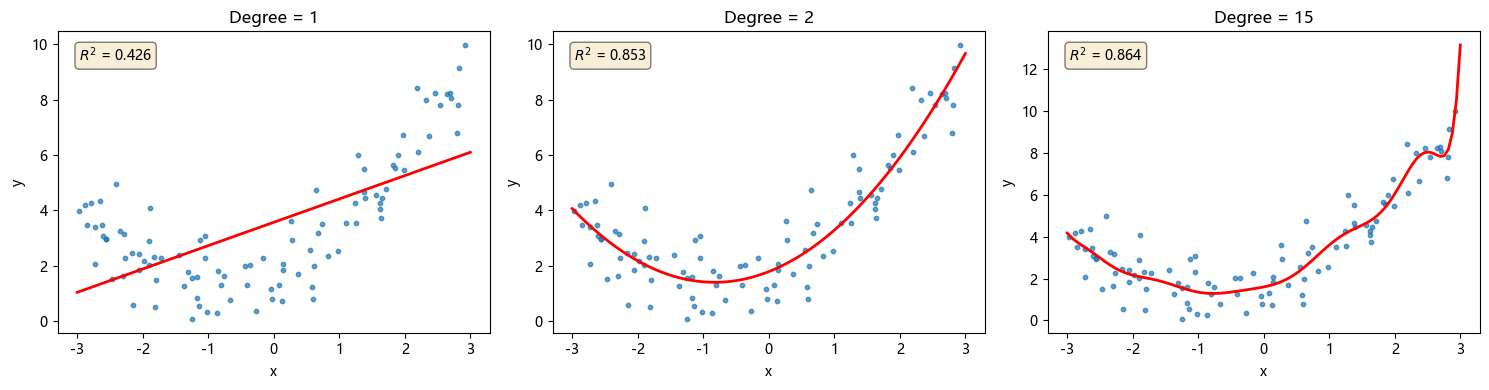

In [28]:
# 尝试不同的阶数 : 1(线性) , 2 , 15(过高)
degrees = [1 , 2 , 15]
plt.figure(figsize=(15 , 4))


for i , degree in enumerate(degrees):
    # 创建子图
    ax = plt.subplot(1 , 3 , i+1)

    # 生成多项式特征并训练模型
    ploy_features = PolynomialFeatures(degree=degree)
    X_poly = ploy_features.fit_transform(X)
    lin_reg = LinearRegression()
    lin_reg.fit(X_poly , y)

    # 预测并绘图
    y_new = lin_reg.predict(ploy_features.transform(X_new))

    ax.scatter(X , y , s = 10 , alpha=0.7)
    ax.plot(X_new , y_new , 'r-' , linewidth=2)
    ax.set_title(f'Degree = {degree}')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    # 计算并显示 R^2 分数(越接近1越好)
    y_pred = lin_reg.predict(X_poly)
    r2 = r2_score(y , y_pred)
    ax.text(0.05, 0.95, f'$R^2$ = {r2:.3f}', transform=ax.transAxes,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
plt.tight_layout()
plt.show()


### 更科学方法 : 交叉验证

根据交叉验证，最佳阶数是: 2


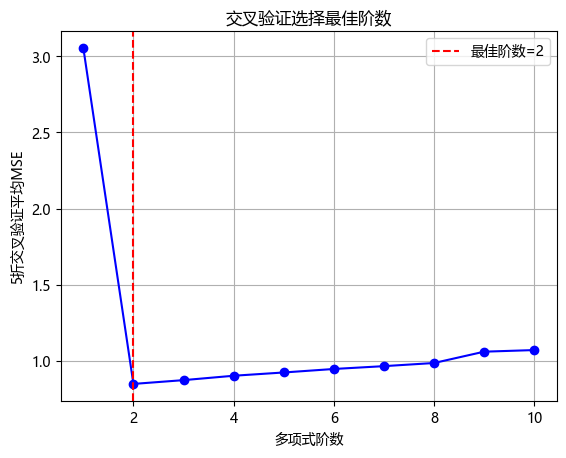

In [29]:
from sklearn.model_selection import cross_val_score

# 测试一系列阶数
degrees_to_try = range(1, 11)
cv_scores = []

for degree in degrees_to_try:
    poly_features = PolynomialFeatures(degree=degree, include_bias=False)
    X_poly = poly_features.fit_transform(X)
    lin_reg = LinearRegression()
    # 使用5折交叉验证，以负均方误差作为评分（sklearn约定：分数越高越好，所以用负MSE）
    scores = cross_val_score(lin_reg, X_poly, y, cv=5, scoring='neg_mean_squared_error')
    cv_scores.append(-scores.mean())  # 取平均并转回正数MSE

# 找到使交叉验证误差最小的阶数
best_degree = degrees_to_try[np.argmin(cv_scores)]
print(f"根据交叉验证，最佳阶数是: {best_degree}")

# 可视化交叉验证误差随阶数的变化
plt.plot(degrees_to_try, cv_scores, 'bo-')
plt.xlabel('多项式阶数')
plt.ylabel('5折交叉验证平均MSE')
plt.title('交叉验证选择最佳阶数')
plt.axvline(x=best_degree, color='r', linestyle='--', label=f'最佳阶数={best_degree}')
plt.legend()
plt.grid(True)
plt.show()